# Key Columns Understanding

- trip_uuid → unique shipment/trip
- source_center → source logistics hub
- destination_center → destination logistics hub
- actual_time → real delivery time
- osrm_time → baseline ETA prediction
- factor → delay multiplier
- route_type → transportation category (FTL/carting)

In [34]:
import pandas as pd
import numpy as np

In [35]:
df = pd.read_csv("../data/raw/delivery_data.csv")

In [36]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(144867, 24)

Columns:
Index(['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type',
       'trip_uuid', 'source_center', 'source_name', 'destination_center',
       'destination_name', 'od_start_time', 'od_end_time',
       'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor',
       'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time',
       'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time',
       'segment_osrm_time', 'segment_osrm_distance', 'segment_factor'],
      dtype='str')

First 5 Rows:


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  str    
 1   trip_creation_time              144867 non-null  str    
 2   route_schedule_uuid             144867 non-null  str    
 3   route_type                      144867 non-null  str    
 4   trip_uuid                       144867 non-null  str    
 5   source_center                   144867 non-null  str    
 6   source_name                     144574 non-null  str    
 7   destination_center              144867 non-null  str    
 8   destination_name                144606 non-null  str    
 9   od_start_time                   144867 non-null  str    
 10  od_end_time                     144867 non-null  str    
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff                  

In [38]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

source_name         293
destination_name    261
dtype: int64


In [39]:
df.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


In [40]:
df["delay_ratio"] = (
    df["actual_time"] / df["osrm_time"]
)

In [41]:
df["delay_ratio"].describe()

count    144867.000000
mean          2.120107
std           1.715421
min           0.144000
25%           1.604264
50%           1.857143
75%           2.213483
max          77.387097
Name: delay_ratio, dtype: float64

In [42]:
print("Unique Source Centers:")
print(df["source_center"].nunique())

print("\nUnique Destination Centers:")
print(df["destination_center"].nunique())

Unique Source Centers:
1508

Unique Destination Centers:
1481


In [43]:
top_sources = df["source_center"].value_counts().head(10)

print(top_sources)

source_center
IND000000ACB    23347
IND562132AAA     9975
IND421302AAG     9088
IND411033AAA     4061
IND501359AAE     3340
IND712311AAA     2612
IND160002AAC     2450
IND395023AAA     2189
IND110037AAM     2013
IND560099AAB     1958
Name: count, dtype: int64


In [44]:
top_destinations = df["destination_center"].value_counts().head(10)

print(top_destinations)

destination_center
IND000000ACB    15192
IND562132AAA    11019
IND421302AAG     5492
IND501359AAE     5142
IND712311AAA     4892
IND110037AAM     3769
IND411033AAA     3695
IND160002AAC     2874
IND131028AAB     2796
IND751002AAB     2524
Name: count, dtype: int64


In [45]:
corridor_stats = (
    df.groupby(["source_center", "destination_center"])
      .agg(
          avg_actual_time=("actual_time", "mean"),
          avg_osrm_time=("osrm_time", "mean"),
          trip_count=("trip_uuid", "count")
      )
      .reset_index()
)

In [46]:
corridor_stats["delay_ratio"] = (
    corridor_stats["avg_actual_time"] /
    corridor_stats["avg_osrm_time"]
)

In [47]:
corridor_stats.head()

,source_center,destination_center,avg_actual_time,avg_osrm_time,trip_count,delay_ratio
0,IND000000AAL,IND411033AAA,63.702703,22.216216,37,2.867397
1,IND000000AAQ,IND700028AAB,78.250000,12.500000,4,6.260000
2,IND000000AAS,IND783370AAC,50.555556,25.888889,18,1.952790
3,IND000000AAZ,IND444203AAA,181.666667,37.666667,3,4.823009
4,IND000000AAZ,IND444303AAA,122.333333,34.333333,3,3.563107


In [48]:
corridor_stats.shape

(2783, 6)

In [49]:
filtered_corridors = corridor_stats[
    corridor_stats["trip_count"] >= 5
].copy()

In [50]:
filtered_corridors.shape

(2203, 6)

In [51]:
top_delayed_corridors = (
    filtered_corridors
    .sort_values("delay_ratio", ascending=False)
    .head(10)
)

top_delayed_corridors

,source_center,destination_center,avg_actual_time,avg_osrm_time,trip_count,delay_ratio
488,IND212402AAA,IND211002AAB,819.107692,22.600000,65,36.243703
1139,IND416606AAA,IND416510AAA,785.460000,29.400000,50,26.716327
485,IND211008AAA,IND211002AAB,296.555556,12.444444,18,23.830357
455,IND208012AAA,IND209304AAA,369.363636,16.515152,33,22.365138
668,IND283122AAB,IND282005AAA,388.000000,19.571429,7,19.824818
1213,IND425405AAA,IND424006AAA,728.111111,42.888889,18,16.976684
2431,IND743270AAA,IND712311AAA,1133.600000,73.800000,5,15.360434
618,IND271001AAA,IND271210AAA,430.714286,29.000000,7,14.852217
2600,IND792121AAB,IND786181AAC,291.920000,21.760000,25,13.415441
476,IND209801AAA,IND209304AAA,314.840000,23.840000,25,13.206376


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

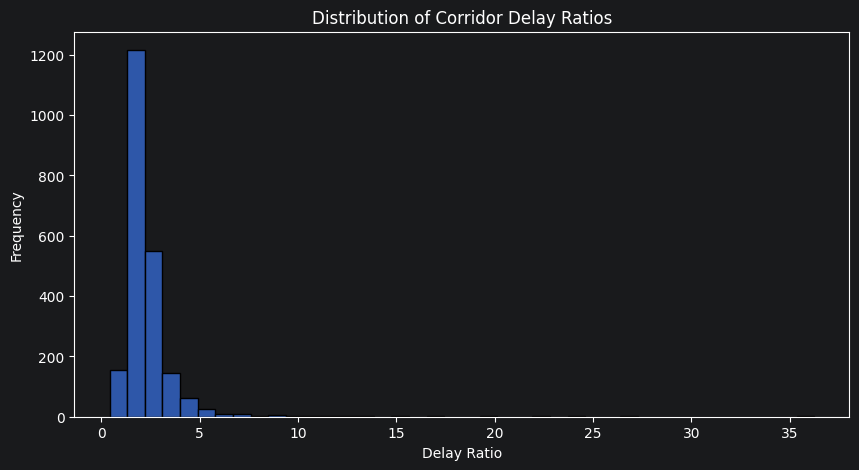

In [53]:
plt.figure(figsize=(10, 5))

sns.histplot(
    filtered_corridors["delay_ratio"],
    bins=40
)

plt.title("Distribution of Corridor Delay Ratios")
plt.xlabel("Delay Ratio")
plt.ylabel("Frequency")

plt.show()

In [54]:
filtered_corridors["delay_ratio"].describe()

count    2203.000000
mean        2.369036
std         1.746341
min         0.422815
25%         1.667065
50%         2.002646
75%         2.506771
max        36.243703
Name: delay_ratio, dtype: float64

### Observations

- Delay ratios are right-skewed with several extreme outliers.
- Most corridors fall within the 1–4 delay ratio range.
- A few routes experience significantly larger delays and may indicate operational bottlenecks.
- Filtered corridor-level aggregation will later be used for graph construction.

In [55]:
filtered_corridors.to_csv(
    "../data/processed/corridor_stats.csv",
    index=False
)

### Observations

- Some corridors show significantly higher delays than OSRM estimates.
- A few high-frequency hubs dominate the logistics network.
- Delay distribution appears right-skewed with visible outliers.
- Corridor-level aggregation will later help in graph edge creation.